In [3]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_adata(adata_to_plot, cluster_key, plot_type="umap"):
    if plot_type == "spatial":

        coords = adata_to_plot.obsm['spatial'].copy()
        df = pd.DataFrame(coords, columns=['x', 'y'], index=adata_to_plot.obs_names)

        df[cluster_key] = adata_to_plot.obs[cluster_key].astype(str)

        tab20 = [mpl.colors.rgb2hex(c) for c in plt.get_cmap('tab20').colors]

        fig = px.scatter(
            df,
            x='x',
            y='y',
            color=cluster_key,
            title='Spatial scatter — manual cell types',
            #color_discrete_sequence=tab20,
            hover_name=df.index,
            width=1600,
            height=700
        )

        fig.update_traces(marker=dict(size=2, opacity=0.8))
        fig.update_yaxes(autorange='reversed')
        fig.update_layout(
            legend_title_text=cluster_key,
            legend=dict(
                itemsizing='constant',
                traceorder='normal',
                bgcolor='rgba(255,255,255,0.5)',
                x=1.02, y=1
            ),
            margin=dict(l=20, r=200, t=50, b=20)
        )

        fig.show()



    elif plot_type == "umap":

        df = pd.DataFrame(
            adata_to_plot.obsm['X_umap'],
            columns=['UMAP1', 'UMAP2'],
            index=adata_to_plot.obs_names
        ).copy()

        df[cluster_key] = adata_to_plot.obs[cluster_key].astype(str)

        tab20 = [mpl.colors.rgb2hex(c) for c in plt.get_cmap('tab20').colors]

        fig = px.scatter(
            df,
            x='UMAP1',
            y='UMAP2',
            color=cluster_key,
            title='UMAP embedding — Leiden clusters',
            color_discrete_sequence=tab20,
            hover_name=df.index,
            width=1400,
            height=1200
        )

        fig.update_traces(marker=dict(size=3, opacity=0.8))
        fig.update_layout(
            legend_title_text='Leiden cluster',
            legend=dict(
                itemsizing='constant',
                traceorder='normal',
                bgcolor='rgba(255,255,255,0.5)',
                x=1.02, y=1
            ),
            margin=dict(l=20, r=200, t=50, b=20)
        )

        fig.show()

In [4]:
import sopa
import spatialdata
import pandas as pd
import scanpy as sc

Tissue = "Region1"
TableFolder = "REGION1_TABLES"
in_out_path = f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/{Tissue}/{TableFolder}"

adata_xenium_p = f"{in_out_path}/{Tissue}_Xenium_Phen_HE_Integrated.Xenium_Process_Table.V2.All_Genes.h5ad"
infile = adata_xenium_p.replace(".V2",".Cell_Type_Annotated_Auto.V3")

adata = sc.read_h5ad(infile)

In [5]:
adata.obs["cell_coord_x"] = pd.DataFrame(adata.obsm["spatial"])[[0]].values
adata.obs["cell_coord_y"] = pd.DataFrame(adata.obsm["spatial"])[[1]].values

cell_coords = pd.DataFrame(adata.obs[["cell_id","leiden","cell_type_xenium_panel","cell_coord_x", "cell_coord_y" ]]).copy()

In [7]:
# import numpy as np
# from matplotlib.path import Path

# def annotate_cells_in_hexagon(cell_coords, cx, cy,diameters, out_coln=None, unique_group=True):
#     for diameter in diameters:
#         r          = diameter / 2.0
#         angles     = np.linspace(0, 2*np.pi, 6, endpoint=False)
#         verts      = np.column_stack((cx + r * np.cos(angles),
#                                     cy + r * np.sin(angles)))
#         hex_path   = Path(verts)
        
#         if out_coln == None:
#             out_col     = f"in_hexagon_{diameter}"
#         else:
#             out_col     = f"in_hexagon_{diameter}_{out_coln}"

#         cell_coords[out_col] = hex_path.contains_points(cell_coords[["cell_coord_x", "cell_coord_y"]].values)

#     just_bool_cols = cell_coords[[f"in_hexagon_{diameter}" for diameter in diameters]]

#     if unique_group:
#         just_bool_cols = just_bool_cols & (just_bool_cols.cumsum(axis=1) == 1)

#     return cell_coords, just_bool_cols


# diameters = [1500, 2500, 3000]
# cell_coords_returned, just_bool_cols_returned = annotate_cells_in_hexagon(cell_coords, 3553, 1709, diameters)



# cell_type = "pericyte"

# adatas = []
# for diameter in diameters:

#     out_col = f"in_hexagon_{diameter}"
#     adata_interested = adata.copy()
#     adata_interested.obs[out_col] = just_bool_cols_returned[out_col].values

#     mask = (
#     adata_interested.obs[out_col] &
#     (adata_interested.obs["cell_type_xenium_panel"] == cell_type)
#     )
#     filtered = adata_interested[mask].copy()

#     # 2) Now add your new obs column
#     filtered.obs["spatial_mark"] = f"in_hexagon_{diameter}"

#     # 3) Append to list
#     adatas.append(filtered)



# adatas

In [8]:
import numpy as np
from matplotlib.path import Path

def hexagon_filter_adatas(
    adata,
    cell_coords,
    cx,
    cy,
    diameters,
    cell_type,
    out_coln=None,
    unique_group=True
):
    """
    1) Annotates `cell_coords` with one column per diameter:
         in_hexagon_{diameter}[_{out_coln}]
    2) (Optionally) enforces that each cell only belongs to its first hexagon.
    3) For each diameter, copies `adata`, adds that boolean as an .obs column,
       filters to the given `cell_type` AND in_hexagon, tags `.obs['spatial_mark']`,
       and returns the list of these sub‐Adatas.

    Returns
    -------
    annotated_cell_coords : pandas.DataFrame
        original `cell_coords` plus the in_hexagon_* columns
    filtered_adatas : list of AnnData
        one filtered AnnData per diameter
    """
    # 1) annotate
    annotated = cell_coords.copy()
    col_names = []
    for diameter in diameters:
        r        = diameter / 2.0
        angles   = np.linspace(0, 2*np.pi, 6, endpoint=False)
        verts    = np.column_stack((cx + r * np.cos(angles),
                                    cy + r * np.sin(angles)))
        hex_path = Path(verts)

        suffix   = f"_{out_coln}" if out_coln else ""
        col      = f"in_hexagon_{diameter}{suffix}"
        annotated[col] = hex_path.contains_points(
            annotated[["cell_coord_x","cell_coord_y"]].values
        )
        col_names.append(col)

    # 2) enforce uniqueness if requested
    if unique_group:
        bools = annotated[col_names]
        first_only = bools & (bools.cumsum(axis=1) == 1)
        annotated[col_names] = first_only

    # 3) build filtered Adatas
    filtered_adatas = []
    for col, diameter in zip(col_names, diameters):
        sub = adata.copy()
        sub.obs[col] = annotated[col].values
        mask = (
            sub.obs[col] &
            (sub.obs["cell_type_xenium_panel"] == cell_type)
        )
        sub2 = sub[mask].copy()
        sub2.obs["spatial_mark"] = col
        filtered_adatas.append(sub2)

    return annotated, filtered_adatas

In [28]:
diameters = [1500, 2500, 3000]
annotated_coords, cell_of_interest_adatas = hexagon_filter_adatas(
    adata=adata,
    cell_coords=cell_coords,
    cx=3553,
    cy=1709,
    diameters=diameters,
    cell_type="prostate_gland_microvascular_endothelial_cell",
    out_coln=None,
    unique_group=True
)
# `annotated_coords` now has in_hexagon_1500, in_hexagon_2500, in_hexagon_3000
# `pericyte_adatas` is a list of three AnnData objects,
# each filtered to pericytes inside the corresponding hexagon.

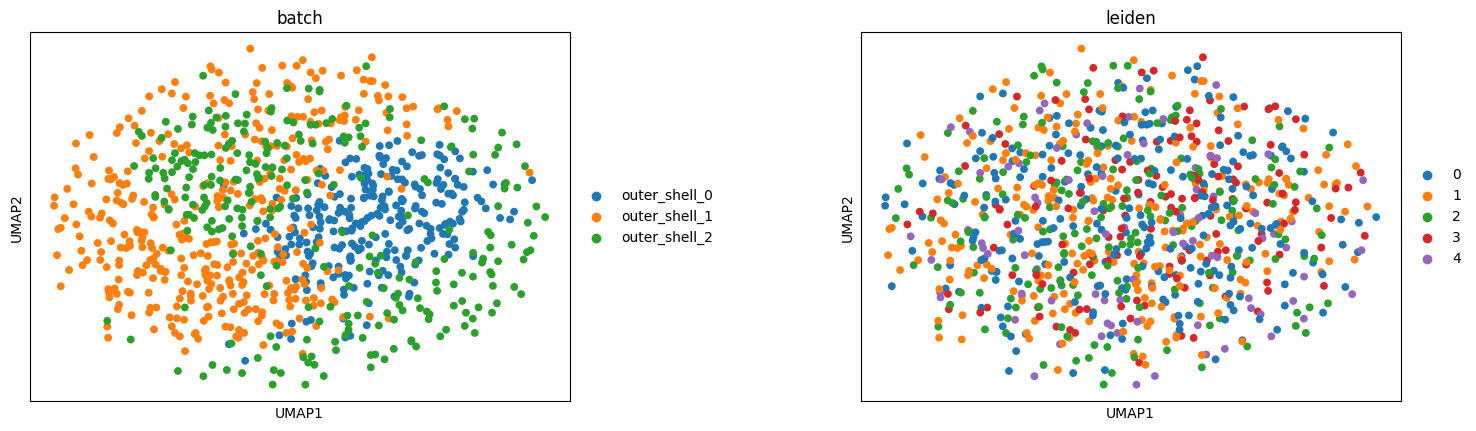

In [29]:
annotated_coords = sc.concat(
    cell_of_interest_adatas,
    join="inner",             # keep only shared genes
    label="batch",            # name of the obs column marking original dataset
    keys=[f"outer_shell_{i}" for i in range(len(cell_of_interest_adatas))]
)

sc.pp.neighbors(
    annotated_coords,
    use_rep="X",              # use raw counts / expression matrix
    n_neighbors=15,
    metric="euclidean"
)

sc.tl.umap(annotated_coords)
sc.tl.leiden(annotated_coords, resolution=1)
sc.pl.umap(annotated_coords, color=["batch", "leiden"], wspace=0.4)

In [30]:
annotated_coords

AnnData object with n_obs × n_vars = 942 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'leiden', 'cell_type', 'cell_type_xenium_panel', 'cell_coord_x', 'cell_coord_y', 'spatial_mark', 'batch'
    uns: 'neighbors', 'umap', 'leiden', 'batch_colors', 'leiden_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    obsp: 'distances', 'connectivities'

In [ ]:
import pandas as pd

adata_spat = adata.copy()

adata_spat.obs = adata_spat.obs.join(
    annotated_coords.obs["spatial_mark"].rename("spatial_mark"),
    how="left"
)

if pd.api.types.is_categorical_dtype(adata_spat.obs["spatial_mark"]):
    adata_spat.obs["spatial_mark"] = (
        adata_spat.obs["spatial_mark"]
        .cat
        .add_categories("out_polygon")
    )

adata_spat.obs["spatial_mark"].fillna("out_polygon", inplace=True)

/var/folders/4p/7h_929nx5qngrf9z7xhfy15w0000gn/T/ipykernel_50004/491901866.py:13: DeprecationWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead

/var/folders/4p/7h_929nx5qngrf9z7xhfy15w0000gn/T/ipykernel_50004/491901866.py:21: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [36]:
plot_adata(adata_spat,"spatial_mark", plot_type="spatial")

In [19]:
plot_adata(adata, "cell_type_xenium_panel", plot_type="spatial")